<a href="https://colab.research.google.com/github/jakebaratto/P-s-Doutorado-/blob/main/Baixar%20dados%20anuais%20do%20MapBiomas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Script para baixar dados temporais anuais das classes do Mapbiomas
Script criado com base no curso Python para Análises Geoespaciais desenvolvido por AmbiGEO (2023).
 Scritp utilizado para desenvolvimento do Pós-Doutorado no Departamento de Geografia da USP
Projeto desenvolvido pela Dr. Jakeline Baratto e financiado pela FAPESP (processo: 2022/02383-3)



# ***Cálculo de expansão de área urbana ao longo dos anos.***

* 1 Acesse a coleção do Mapbiomas
* 2 Filtrar a base de dados
* 3 Cálculo de área
* 4 Gere um gráfico

https://tutorials.geemap.org/ImageCollection/mapping_over_image_collection/


Aqui é pra instalar o GEE

In [ ]:
## Instalando as bibliotecas
!pip install geemap earthengine-api geopandas descartes pyproj rtree -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.1 MB/s eta 0:00:00


Aqui conecta com o drive, tu vai ter que autorizar
Abre um nova aba




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instalação de outras bibliotecas

In [ ]:
##Importar bibliotecas
import pandas as pd
import numpy as np
import geemap
import ee
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import json

Aqui contecta com o teu GEE

In [ ]:
##Autenticação
ee.Authenticate()
ee.Initialize(project ='ee-pmbterassi-mapbiomas')

# **MAPBIOMAS**

In [ ]:
##Defindo a coleção de imagem  - acessar o asset de dados no Google Earth Engine: ID: projects/mapbiomas-workspace/public/collection7/mapbiomas_collection70_integration_v2
path_project = 'projects/mapbiomas_af_trinacional/public/collection4/mapbiomas_atlantic_forest_collection4_integration_v1'

##Define a imagem collection
mapbiomas = ee.Image(path_project)
print('Dados MapBiomas',mapbiomas.bandNames().getInfo())

EEException: Image.load: Image asset 'projects/mapbiomas_af_trinacional/public/collection4/mapbiomas_atlantic_forest_collection4_integration_v1' not found (does not exist or caller does not have access).

In [ ]:
##Palette MapBiomas - https://mapbiomas-br-site.s3.amazonaws.com/downloads/_EN__C%C3%B3digos_da_legenda_Cole%C3%A7%C3%A3o_7.pdf
palette_list = ['#ffffff','#129912','#1f4423','#006400','#00ff00','#687537','#76a5af','#29eee4',
'#77a605','#ad4413','#bbfcac','#45c2a5','#b8af4f','#f1c232','#ffffb2','#ffd966',
'#f6b26b','#f99f40','#e974ed','#d5a6bd','#c27ba0','#fff3bf','#ea9999','#dd7e6b',
'#aa0000','#ff8585','#0000ff','#d5d5e5','#dd497f','#665a3a','#ff0000','#1f0478',
'#968c46','#0000ff','#4fd3ff','#ba6a27','#f3b4f1','#02106f','#02106f','#e075ad',
'#982c9e','#e787f8','#ebebe0','#c2c2a3','#6b6b47','#d0ffd0','#cca0d4','#d082de',
'#cd49e4','#6b9932','#66ffcc','#000000','#000000','#000000','#000000','#000000',
'#000000','#CC66FF','#FF6666','#006400','#8d9e8b','#84ff75','#faf87d']


In [ ]:
##Visualizando dados do MapBiomas
Map = geemap.Map(location=[-23,-45], zoom=8)

# Mapbiomas layer
map_2003 = mapbiomas.select('classification_2003')
map_2022 = mapbiomas.select('classification_2022')

# show
Map.addLayer(map_2003, {'palette':palette_list, 'min':0, 'max':62},'2003')
Map.addLayer(map_2022, {'palette':palette_list, 'min':0, 'max':62},'2022')



# **Definindo uma região de interesse**

Aqui é a área de interesse, mas tu precisa estar inslado primeiro no GEE

In [ ]:
##Definindo região
##Região
#region =  ee.FeatureCollection ('projects/ee-jakelinebarattogeo/assets/BH_parana3')
#region =  ee.FeatureCollection ('projects/ee-jakelinebarattogeo/assets/BH_parana3')
region =  ee.FeatureCollection ('projects/ee-pmbterassi-mapbiomas/assets/TFI_ARG')


In [ ]:
#region = ee.FeatureCollection('users/jakelinebarattogeo/US_SCCI_WGS84')
#region = region.select(['NOME_UC1','geometry'])
#region = region.filter(ee.Filter.eq('NOME_UC1', 'PEIC'))
#region

In [ ]:
##Recortando nossa base para a região de interesse
reg_2003= map_2003.clip(region)
reg_2022 = map_2022.clip(region)

In [ ]:
##Visualizando dados do MapBiomas
Map= geemap.Map(location=[-25.08,-47.22], zoom=8)

Map.addLayer(reg_2003,{'palette':palette_list, 'min':0,'max':62},'SCCI 2003')
Map.addLayer(reg_2022,{'palette':palette_list, 'min':0,'max':62},'SCII 2022')



#**Cálculo de área e evolução de classes**

In [ ]:
##Cálculo de área  fonte: https://mapbiomas-br-site.s3.amazonaws.com/downloads/_EN__C%C3%B3digos_da_legenda_Cole%C3%A7%C3%A3o_7.pdf
Urban_Area= 24
Forest = 1

##Loop para criar uma image collection a partir das bandas o Mapbiomas
lista = ee.List.sequence(0, 24)
years = ee.List.sequence(1998, 2022)

##Função
def collection_image(number):
  matchKey = ee.String(ee.List(mapbiomas.bandNames()).get(number))##vamos selecionar
                                                                    ##o valor da lista das bandas

  # urban = ee.Image(mapbiomas).select(matchKey).eq(Urban_Area).selfMask().rename('urban');##selcionando apenas a classe de interesse
  # forest = ee.Image(mapbiomas).select(matchKey).eq(Forest).selfMask().rename('forest');##selcionando apenas a classe de interesse

  image = ee.Image(mapbiomas).select(matchKey)
  return image.set('year', years.get(number))\
               .set('system:time_start', ee.Date.fromYMD(years.get(number), 1, 1))\
                .clip(region)

##Aplicando a função sobre a lista
listImages = lista.map(collection_image)

##Criando nossa coleção de imagens
imageCollection = ee.ImageCollection.fromImages(listImages)
print('Coleção de imagens',imageCollection.size().getInfo())

Coleção de imagens 25


In [ ]:
##Função para download
download = ee.batch.Export.imageCollection.toDrive(imageCollection.limit(18),##Retirar o .limit(3) apenas para exemplificar
                                                      region=region.geometry(region),
                                                      folder='Classe_mapbiomas',
                                                      scale=30,
                                                      crs='EPSG:4674', ##sirgas 2000 epsg:4674
                                                      maxPixels=1e13,
                                                      fileFormat='GeoTIFF') #Salvará as imagens automaticamente do Drive

AttributeError: type object 'Export' has no attribute 'imageCollection'

In [ ]:
##Verificando as bandas
imageCollection.first().bandNames()

In [ ]:
##Quantas imagens
count = imageCollection.size().getInfo()
year_list = years.getInfo()
lista_list= lista.getInfo()


In [ ]:
year_list

[1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022]

# **Cálculo de área por ano**

In [ ]:
### Inserção do nome da classe
dicionario_classes = {
    0:"Fora da área de interesse", 1:"Floresta", 3:"Formação Florestal",
    4:"Formação Savânica", 5:"Mangue", 49:"Restinga Arborizada",  10:"Formação Natural não Florestal",
    11:"Campo Alagado e Área Pantanosa",   12:"Formação Campestre",
    32:"Apicum",   29:"Afloramento Rochoso",   50:"Restinga Herbácea",
    13:"Outras Formações não Florestais",  14:"Agropecuária",
    15:"Pastagem",   18:"Agricultura",
    19:"Lavoura Temporária",   39:"Soja",
    20:"Cana",   40:"Arroz (beta)",   62:"Algodão (beta)",
    41:"Outras Lavouras Temporárias", 36:"Lavoura Perene",  46:"Café",
    47:"Citrus",  48:"Outras Lavouras Perenes",  9:"Silvicultura",
    21:"Mosaico de Usos",  22:"Área não Vegetada",  23:"Praia, Duna e Areal",
    24:"Área Urbanizada",  30:"Mineração", 25:"Outras Áreas não Vegetadas",
    26:"Corpo D'água", 33:"Rio, Lago e Oceano",
    31:"Aquicultura", 27:"Não observado"
}

### Inserção das cores de legenda
dicionario_cores = {
    0:"white", 1:"#129912",
    3:"#006400", 4:"#00ff00",
    5:"#687537", 49:"#6b9932",
    10:"#bbfcac", 11:"#45c2a5",
    12:"#b8af4f", 32:"#968c46",
    29:"#ff8C00", 50:"#66ffcc",
    13:"#bdb76b",
    14:"#ffffb2",
    15:"#ffd966",
    18:"#e974ed",
    19:"#d5a6bd",
    39:"#c59ff4",
    20:"#c27ba0",
    40:"#982c9e",
    62:"#660066",
    41:"#e787f8",
    36:"#f3b4f1",
    46:"#cca0d4",
    47:"#d082de",
    48:"#cd49e4",
    9:"#935132",
    21:"#fff3bf",
    22:"#ea9999",
    23:"#dd7e6b",
    24:"#af2a2a",
    30:"#8a2be2",
    25:"#ff99ff",
    26:"#0000ff",
    33:"#0000ff",
    31:"#29eee4",
    27:"#D5D5E5"
}

## paleta
paleta_nomes = {key:value for key, value in zip(dicionario_classes.values(), dicionario_cores.values())}


In [ ]:
##Abrindo todas as imagens
##Calcular a área para todas as imagens
df = []

##Calcular a área e gera o dataframe
for i in range(0,count,1): ######################ALTEREI PARA 5 ANOS#################################
    image = ee.Image((listImages).get(i))

    ##Calculo de área dos pixels de classificação
    areaImage = ee.Image.pixelArea().divide(1e6).addBands(image);

    ##Agrupando valores
    areas = areaImage.reduceRegion(**{
    ##Agrupa os registros do redutor pelo valor de uma determinada entrada e reduz
    ##cada grupo com o redutor fornecido.
      'reducer': ee.Reducer.sum().group(**{
      'groupField': 1,
      'groupName': 'classification'+'_'+str(year_list[i]),
    }),
    'geometry': region,
    'scale': 30,
    'bestEffort': True,
    'maxPixels': 1e13
    })

    # Criando uma lista para extrair o valor da área
    lista = areas.get('groups').getInfo()

    # Transformando a lista em Dataframe
    area_df = pd.DataFrame(lista, columns=['classification'+'_'+str(year_list[i]),'sum'])

    ##Adicionando uma coluna com o ano
    area_df['ano'] = int(year_list[i])
    ##Area_km2 =
    area_df['area'] = area_df['sum'].round(2)
    # Adicionando uma coluna com número da classe para renomear de acordo com o dicionário
    area_df['classe'] = area_df['classification_'+str(year_list[i])]
    ##Renomeando considerando o lugar
    area_df['nome_classe']= area_df['classe'].replace(dicionario_classes)
    ##Removendo colunas
    area_df = area_df.drop(columns=['classification_'+str(year_list[i]),'sum'], axis = 1)

    ##Juntado o DataFrame com a lista vazia criada
    df.append(area_df)

In [ ]:
## cria um dataframe completo
df_completo = pd.concat(df, axis = 'index')
df_completo.round(2).head()

,ano,area,classe,nome_classe
0,1998,0.00,0,Fora da área de interesse
1,1998,1803.22,3,Formação Florestal
2,1998,553.87,9,Silvicultura
3,1998,3.05,15,Pastagem
4,1998,2.97,18,Agricultura


In [ ]:
## criando coluna de classe e de área
df_melt = pd.melt(df_completo, id_vars=['ano','classe','nome_classe'],value_vars='area', value_name="Area_km_2",var_name='Área_classe').dropna()
df_melt.head()

,ano,classe,nome_classe,Área_classe,Area_km_2
0,1998,0,Fora da área de interesse,area,0.00
1,1998,3,Formação Florestal,area,1803.22
2,1998,9,Silvicultura,area,553.87
3,1998,15,Pastagem,area,3.05
4,1998,18,Agricultura,area,2.97


Aqui é pra exportar a tabela pro drive


In [ ]:
export_precipit = df_melt.to_csv ('/content/drive/MyDrive/MapBiomas/TFI_ARG_1998_2022.csv')

ValueError: keyword grid_b is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_caps

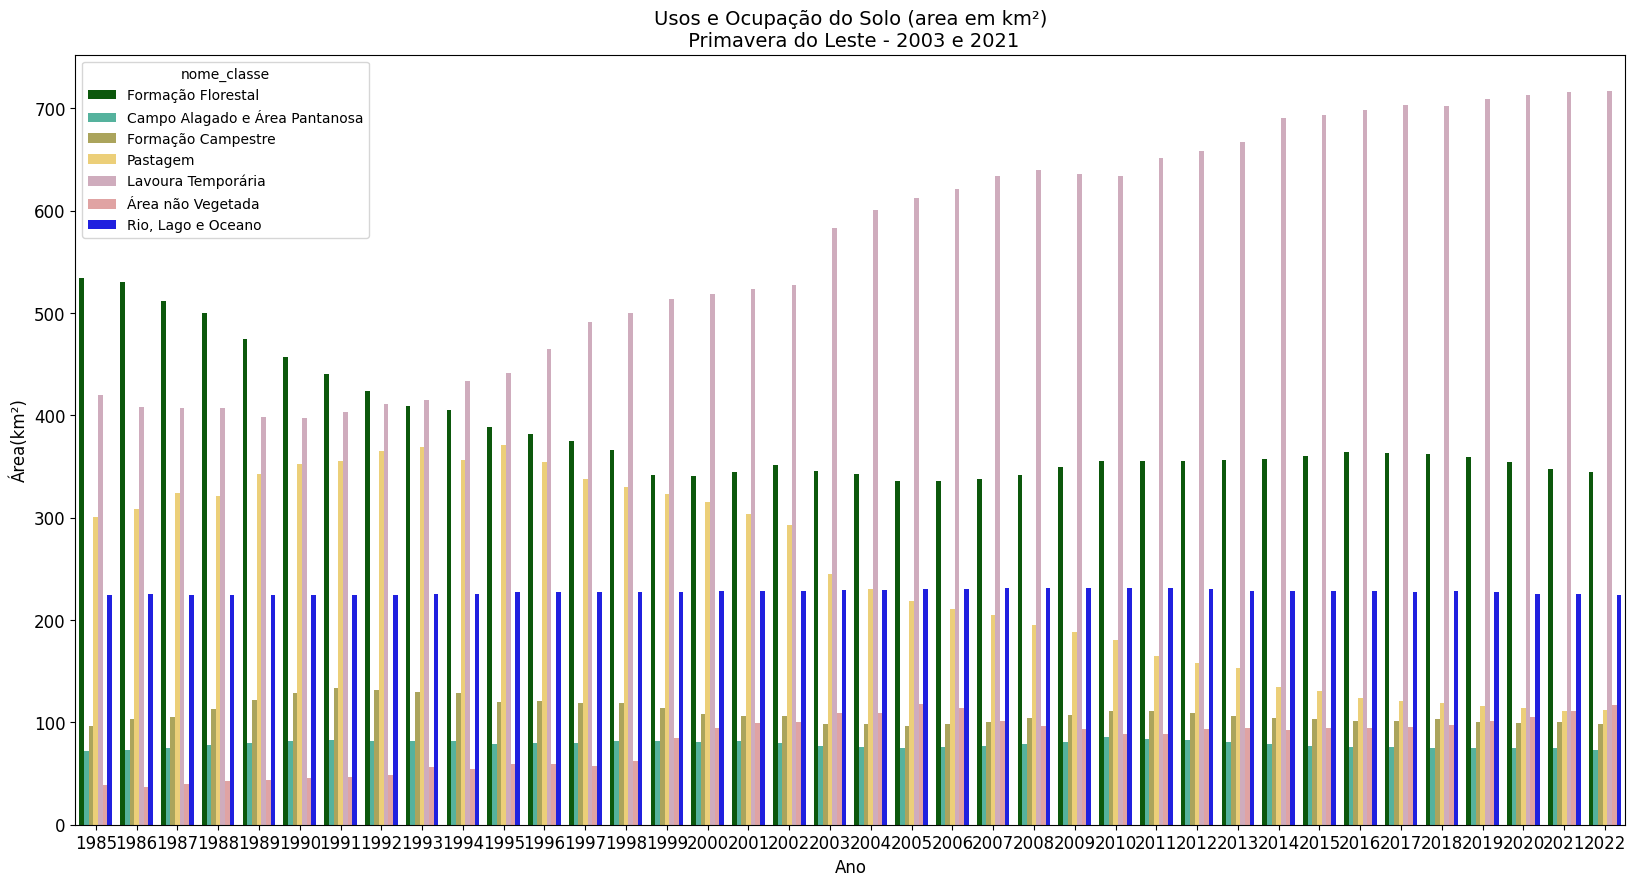

In [ ]:
## Plot geral - evolução do uso do solo
import matplotlib.pyplot as plt
import seaborn as sns


fig, ax = plt.subplots(figsize=(20,10))
sns.barplot(data=df_melt, x="ano", y="Area_km_2", hue="nome_classe", palette=paleta_nomes)

#Título
plt.title('Usos e Ocupação do Solo (area em km²)\n Primavera do Leste - 2003 e 2021', fontsize =14)

##eixo x
plt.xlabel('Ano',fontsize=12)
plt.xticks(fontsize=12)
##eixo y
plt.ylabel('Área(km²)',fontsize=12)
plt.yticks(fontsize=12)

##Personalizando o gráfico
plt.grid(b=True, linestyle='--', linewidth=0.2, which='both')
ax.legend(loc="upper right",bbox_to_anchor=(1.25, 1), title = "Legenda", title_fontsize = "12", fontsize='12')

# **Verificando a expansão da área urbana e demais classes**

In [ ]:
##Selecionar apenas a classe área urbana
df_urban=df_melt[df_melt.nome_classe=='Área Urbanizada']
df_urban

,ano,classe,nome_classe,Área_classe,Area_km_2
6,1985,24,Área Urbanizada,area,117.77
19,1986,24,Área Urbanizada,area,129.22
32,1987,24,Área Urbanizada,area,132.84
45,1988,24,Área Urbanizada,area,137.74
58,1989,24,Área Urbanizada,area,142.46
71,1990,24,Área Urbanizada,area,145.57
84,1991,24,Área Urbanizada,area,148.42
96,1992,24,Área Urbanizada,area,150.32
108,1993,24,Área Urbanizada,area,152.21
120,1994,24,Área Urbanizada,area,154.07


In [ ]:
df_mangue =df_melt[df_melt.nome_classe=='Mangue']
df_mangue

,ano,classe,nome_classe,Área_classe,Area_km_2
1,1985,5,Mangue,area,93.29
18,1986,5,Mangue,area,94.46
35,1987,5,Mangue,area,94.48
52,1988,5,Mangue,area,96.10
69,1989,5,Mangue,area,95.01
86,1990,5,Mangue,area,93.47
102,1991,5,Mangue,area,92.02
118,1992,5,Mangue,area,92.12
134,1993,5,Mangue,area,91.68
150,1994,5,Mangue,area,91.02


In [ ]:
##Dataframe para soja
df_agro=df_melt[df_melt.nome_classe=='Soja']
df_agro

,ano,classe,nome_classe,Área_classe,Area_km_2
9,1985,39,Soja,area,1699.73
22,1986,39,Soja,area,3298.27
35,1987,39,Soja,area,3833.73
48,1988,39,Soja,area,4050.84
61,1989,39,Soja,area,3766.50
74,1990,39,Soja,area,3525.81
87,1991,39,Soja,area,3189.10
99,1992,39,Soja,area,3314.43
111,1993,39,Soja,area,3575.87
123,1994,39,Soja,area,3631.51


In [ ]:
##Selecionar apenas a classe área urbana
df_rest=df_melt[df_melt.nome_classe=='Restinga Arborizada']
df_rest

,ano,classe,nome_classe,Área_classe,Area_km_2
15,1985,49,Restinga Arborizada,area,1520.32
32,1986,49,Restinga Arborizada,area,1510.68
49,1987,49,Restinga Arborizada,area,1504.21
66,1988,49,Restinga Arborizada,area,1500.57
83,1989,49,Restinga Arborizada,area,1504.40
99,1990,49,Restinga Arborizada,area,1509.32
115,1991,49,Restinga Arborizada,area,1511.94
131,1992,49,Restinga Arborizada,area,1517.32
147,1993,49,Restinga Arborizada,area,1521.83
163,1994,49,Restinga Arborizada,area,1519.62


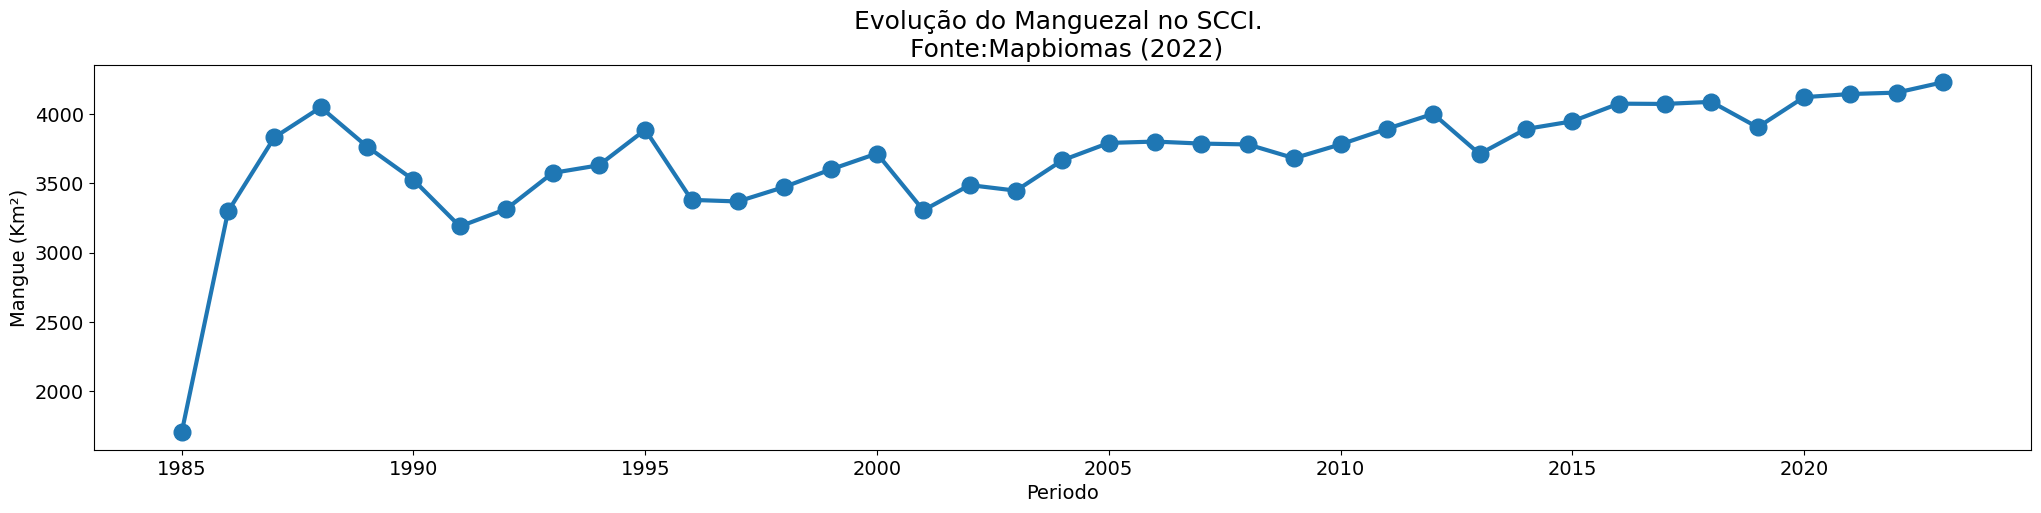

In [ ]:
##Definindo o tamando da figura
fig, ax = plt.subplots(figsize=(25,5))

##Definindo o x e o y da figura
x = df_agro['ano']
y = df_agro['Area_km_2']

#Título
plt.title('Evolução do Manguezal no SCCI. \n Fonte:Mapbiomas (2022)', fontsize=18)

##Definir marcação
plt.plot(x, y, marker='o', linewidth=3, markersize=12) ##dados de área
##Eixo x
plt.xlabel('Periodo',fontsize=14)
plt.xticks(rotation=0,fontsize=14)

##Eixo Y
plt.ylabel('Mangue (Km²)',fontsize=14)
plt.yticks(fontsize=14)

plt.show()

NameError: name 'df_mangue' is not defined

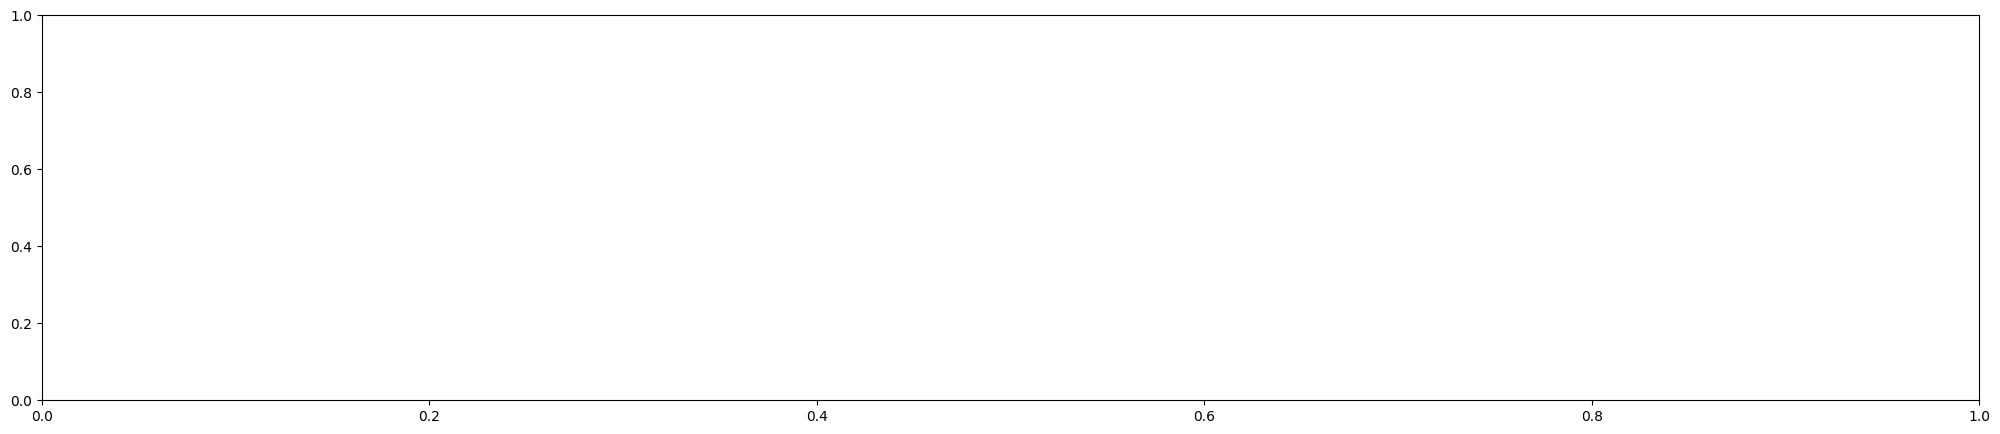

In [ ]:
##Definindo o tamando da figura
fig, ax = plt.subplots(figsize=(25,5))

##Definindo o x e o y da figura
x = df_urban['ano']
y = df_mangue['Area_km_2']
y2 = df_rest['Area_km_2']

#Título
plt.title('Soja e Formação Florestal no Município de Primavera do Leste - MT. \n Fonte:Mapbiomas (2022)', fontsize=18)

##Definir marcação
plt.plot(x, y, marker='o', linewidth=3, markersize=12, color='purple') ##dados de área
plt.plot(x, y2, marker='x', linewidth=3, markersize=12, color='green') ##dados de área
##Eixo x
plt.xlabel('Periodo',fontsize=14)
plt.xticks(rotation=0,fontsize=14)

##Eixo Y
plt.ylabel('Área Urbana (Km²)',fontsize=14)
plt.yticks(fontsize=14)

plt.show()